# E-commerce Customer Behavior Analysis

## Этап 1. Знакомство с данными

Цель этапа - изучить структуру исходных таблиц и выявить потенциальные проблемы качества
данных до начала анализа

_Бизнес-задача_: убедиться, что данные открываются корректно, а Pandas правильно распознает структуру

In [43]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
current_dir = Path.cwd()

project_dir = (
    current_dir
    if (current_dir / "data").exists()
    else current_dir.parent
)

raw_data_dir = project_dir / "data" / "raw"

print("Рабочая директория:", current_dir)
print("Корень проекта:", project_dir)
print("Папка с данными:", raw_data_dir)
print("Папка существует:", raw_data_dir.exists())

Рабочая директория: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\notebooks
Корень проекта: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis
Папка с данными: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\data\raw
Папка существует: True


In [45]:
for file_path in raw_data_dir.glob("*.csv"):
    print(file_path.name)

category_tree.csv
events.csv
item_properties_part1.csv
item_properties_part2.csv


In [46]:
events = pd.read_csv(raw_data_dir / "events.csv")
categories = pd.read_csv(raw_data_dir / "category_tree.csv")

In [47]:
item_properties_sample = pd.concat(
    [
        pd.read_csv(
            raw_data_dir / "item_properties_part1.csv",
            nrows=100_000,
        ),
        pd.read_csv(
            raw_data_dir / "item_properties_part2.csv",
            nrows=100_000,
        ),
    ],
    ignore_index=True,
)

In [48]:
print("events:", events.shape)
print("categories:", categories.shape)
print("item_properties_sample:", item_properties_sample.shape)

events: (2756101, 5)
categories: (1669, 2)
item_properties_sample: (200000, 4)


In [49]:
display(events.head())
display(categories.head())
display(item_properties_sample.head())

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [50]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          str    
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 105.1 MB


In [51]:
item_properties_sample["property"].value_counts().head(10)

property
888           29536
790           17961
available     14645
categoryid     7798
6              6331
283            5925
776            5761
678            4746
364            4726
202            4395
Name: count, dtype: int64

In [52]:
print(
    "Строк с categoryid:",
    item_properties_sample["property"].eq("categoryid").sum()
)

Строк с categoryid: 7798


In [53]:
category_properties = item_properties_sample[
    item_properties_sample["property"] == "categoryid"
].copy()

print("Количество строк:", len(category_properties))
print(
    "Уникальных товаров:",
    category_properties["itemid"].nunique()
)
print(
    "Уникальных значений категорий:",
    category_properties["value"].nunique()
)

Количество строк: 7798
Уникальных товаров: 7798
Уникальных значений категорий: 734


In [54]:
category_properties["itemid"].value_counts().head(10)

itemid
460429    1
281245    1
35575     1
8313      1
55102     1
397079    1
265036    1
124459    1
350508    1
221365    1
Name: count, dtype: int64

_Бизнес-смысл проверки_: нам нужно понять, менялась ли категория товара со временем или в таблице просто повторяются одинаковые состояния

In [55]:
category_properties.groupby("itemid").size().sort_values(
    ascending=False
).head(10)

itemid
40     1
52     1
216    1
218    1
273    1
375    1
538    1
602    1
655    1
727    1
dtype: int64

In [56]:
print("Строк:", len(category_properties))
print("Уникальных товаров:", category_properties["itemid"].nunique())

Строк: 7798
Уникальных товаров: 7798


In [57]:
property_files = [
    raw_data_dir / "item_properties_part1.csv",
    raw_data_dir / "item_properties_part2.csv",
]

category_parts = []

for file_path in property_files:
    for chunk in pd.read_csv(file_path, chunksize=500_000):
        category_chunk = chunk.loc[
            chunk["property"].eq("categoryid"),
            ["timestamp", "itemid", "value"],
        ]
        category_parts.append(category_chunk)

category_history = pd.concat(
    category_parts,
    ignore_index=True,
)

category_history.shape

(788214, 3)

In [58]:
print("Строк:", len(category_history))
print("Уникальных товаров:", category_history["itemid"].nunique())
print("Уникальных категорий:", category_history["value"].nunique())
print(
    "Максимум записей на один товар:",
    category_history.groupby("itemid").size().max(),
)

Строк: 788214
Уникальных товаров: 417053
Уникальных категорий: 1242
Максимум записей на один товар: 18


In [59]:
category_stats = (
    category_history
    .groupby("itemid")
    .agg(
        records_count=("value", "size"),
        unique_categories=("value", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
)

category_stats.head()

,records_count,unique_categories,first_timestamp,last_timestamp
itemid,,,,
0,1,1,1431226800000,1431226800000
1,1,1,1431226800000,1431226800000
2,1,1,1431226800000,1431226800000
3,1,1,1433041200000,1433041200000
4,1,1,1431831600000,1431831600000


In [60]:
category_stats["records_count"].value_counts().sort_index()

records_count
1     393701
2          3
3          5
5         37
6         52
7         15
8        359
9       1358
10        34
11       139
12       223
13       520
14       131
15       133
16       387
17      1738
18     18218
Name: count, dtype: int64

In [61]:
changed_category = category_stats["unique_categories"] > 1

print(
    "Товаров с несколькими категориями:",
    changed_category.sum(),
)

print(
    "Доля таких товаров:",
    changed_category.mean(),
)

Товаров с несколькими категориями: 23352
Доля таких товаров: 0.0559928833985129


In [62]:
print(
    f"Доля товаров с несколькими категориями: "
    f"{changed_category.mean():.2%}"
)

Доля товаров с несколькими категориями: 5.60%


In [63]:
changed_items = category_stats[
    category_stats["unique_categories"] > 1
].head()

changed_items

,records_count,unique_categories,first_timestamp,last_timestamp
itemid,,,,
25,18,2,1431226800000,1442113200000
94,18,2,1431226800000,1442113200000
130,18,2,1431226800000,1442113200000
149,18,2,1431226800000,1442113200000
168,18,2,1431226800000,1442113200000


In [64]:
item_id = changed_items.index[0]

category_history[
    category_history["itemid"] == item_id
].sort_values("timestamp")

,timestamp,itemid,value
301304,1431226800000,25,1509
324559,1431831600000,25,1509
332279,1432436400000,25,1509
347563,1433041200000,25,1509
309009,1433646000000,25,1509
316780,1434250800000,25,1509
339919,1435460400000,25,1509
370569,1436065200000,25,1509
362920,1436670000000,25,1509
355258,1437274800000,25,1509


In [65]:
multiple_records = category_stats["records_count"] > 1
multiple_categories = category_stats["unique_categories"] > 1

print("Несколько записей:", multiple_records.sum())
print("Несколько категорий:", multiple_categories.sum())
print(
    "Условия полностью совпадают:",
    multiple_records.equals(multiple_categories),
)

Несколько записей: 23352
Несколько категорий: 23352
Условия полностью совпадают: True


In [66]:
category_history["datetime"] = pd.to_datetime(
    category_history["timestamp"],
    unit="ms",
    utc=True,
)

In [67]:
category_history[
    category_history["itemid"] == 25
].sort_values("datetime")

,timestamp,itemid,value,datetime
301304,1431226800000,25,1509,2015-05-10 03:00:00+00:00
324559,1431831600000,25,1509,2015-05-17 03:00:00+00:00
332279,1432436400000,25,1509,2015-05-24 03:00:00+00:00
347563,1433041200000,25,1509,2015-05-31 03:00:00+00:00
309009,1433646000000,25,1509,2015-06-07 03:00:00+00:00
316780,1434250800000,25,1509,2015-06-14 03:00:00+00:00
339919,1435460400000,25,1509,2015-06-28 03:00:00+00:00
370569,1436065200000,25,1509,2015-07-05 03:00:00+00:00
362920,1436670000000,25,1509,2015-07-12 03:00:00+00:00
355258,1437274800000,25,1509,2015-07-19 03:00:00+00:00


**Промежуточный вывод**

В таблице свойств найдено 417053 товаров с указанной категорией. Для 23352 товаров (5,6%) наблюдалось более одного значения категории. Например, товар 25 до 9 августа 2015 года относился к категории 1509, а начиная с 16 августа - к категории 72. Следовательно, категория товара может изменяться со временем, что необходимо учитывать при объединении свойств товаров с событиями пользователей

In [68]:
events["datetime"] = pd.to_datetime(
    events["timestamp"],
    unit="ms",
    utc=True,
)

print("Начало периода:", events["datetime"].min())
print("Конец периода:", events["datetime"].max())
print("Продолжительность:", events["datetime"].max() - events["datetime"].min())

Начало периода: 2015-05-03 03:00:04.384000+00:00
Конец периода: 2015-09-18 02:59:47.788000+00:00
Продолжительность: 137 days 23:59:43.404000


In [69]:
events["event"].value_counts(dropna=False)

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

In [70]:
transaction_check = (
    events
    .groupby("event")
    .agg(
        events_count=("event", "size"),
        transactionid_filled=("transactionid", "count"),
    )
)

transaction_check["transactionid_missing"] = (
    transaction_check["events_count"]
    - transaction_check["transactionid_filled"]
)

transaction_check

,events_count,transactionid_filled,transactionid_missing
event,,,
addtocart,69332,0,69332
transaction,22457,22457,0
view,2664312,0,2664312


**Проверка пропусков в transactionid**

Поле `transactionid` заполнено во всех 22 457 событиях типа
`transaction` и отсутствует для событий `view` и `addtocart`.
Эти пропуски являются структурными: идентификатор транзакции
неприменим к действиям, которые не являются покупкой. Удаление или
заполнение таких пропусков не требуется

In [71]:
print("Полных дубликатов:", events.duplicated().sum())
print("\nПропуски по колонкам:")
display(events.isna().sum())

Полных дубликатов: 460

Пропуски по колонкам:


timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
datetime               0
dtype: int64

In [72]:
duplicate_mask = events.duplicated(keep=False)

duplicate_rows = (
    events.loc[duplicate_mask]
    .sort_values(
        [
            "visitorid",
            "timestamp",
            "event",
            "itemid",
            "transactionid",
        ]
    )
)

print(
    "Всего строк, участвующих в дубликатах:",
    len(duplicate_rows),
)

print("\nЛишних повторных строк:")
display(
    events.loc[events.duplicated(), "event"]
    .value_counts()
)

display(duplicate_rows.head(20))

Всего строк, участвующих в дубликатах: 918

Лишних повторных строк:


event
addtocart    366
view          94
Name: count, dtype: int64

,timestamp,visitorid,event,itemid,transactionid,datetime
1041548,1440547735041,745,addtocart,246164,NaN,2015-08-26 00:08:55.041000+00:00
1051024,1440547735041,745,addtocart,246164,NaN,2015-08-26 00:08:55.041000+00:00
301904,1434501277715,3926,addtocart,323347,NaN,2015-06-17 00:34:37.715000+00:00
319376,1434501277715,3926,addtocart,323347,NaN,2015-06-17 00:34:37.715000+00:00
113491,1433611737367,10162,addtocart,146661,NaN,2015-06-06 17:28:57.367000+00:00
124035,1433611737367,10162,addtocart,146661,NaN,2015-06-06 17:28:57.367000+00:00
1965082,1432707397977,12046,addtocart,205663,NaN,2015-05-27 06:16:37.977000+00:00
1983425,1432707397977,12046,addtocart,205663,NaN,2015-05-27 06:16:37.977000+00:00
1166547,1441151647762,12560,addtocart,272976,NaN,2015-09-01 23:54:07.762000+00:00
1167841,1441151647762,12560,addtocart,272976,NaN,2015-09-01 23:54:07.762000+00:00


In [73]:
duplicate_rate = events.duplicated().mean()

print(f"Доля полных дубликатов: {duplicate_rate:.4%}")

Доля полных дубликатов: 0.0167%


**Проверка полных дубликатов**

Обнаружено 460 полных дубликатов, что составляет около 0,0167%
наблюдений. Из них 366 относятся к добавлению товара в корзину,
а 94 - к просмотрам. Дубликатов среди транзакций не обнаружено

В повторяющихся строках совпадают пользователь, товар, тип события
и время с точностью до миллисекунды. Такие записи предварительно
рассматриваются как технические дубликаты и будут удалены на этапе
очистки данных

In [74]:
duplicate_groups = (
    events
    .groupby(
        [
            "timestamp",
            "visitorid",
            "event",
            "itemid",
            "transactionid",
        ],
        dropna=False,
    )
    .size()
)

duplicate_groups = duplicate_groups[duplicate_groups > 1]

duplicate_groups.value_counts().sort_index()

2    456
3      2
Name: count, dtype: int64

_Бизнес-смысл_: дерево категорий понадобится, чтобы объединять товары в более крупные группы

In [75]:
display(categories.head())
categories.info()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


In [76]:
print("Количество строк:", len(categories))
print(
    "Уникальных categoryid:",
    categories["categoryid"].nunique(),
)
print(
    "Уникальных parentid:",
    categories["parentid"].nunique(),
)
print(
    "Полных дубликатов:",
    categories.duplicated().sum(),
)

print("\nПропуски:")
display(categories.isna().sum())

Количество строк: 1669
Уникальных categoryid: 1669
Уникальных parentid: 362
Полных дубликатов: 0

Пропуски:


categoryid     0
parentid      25
dtype: int64

In [77]:
print(
    "Повторяющихся categoryid:",
    categories["categoryid"].duplicated().sum(),
)

print(
    "Категорий, являющихся родителями самим себе:",
    categories["categoryid"]
    .eq(categories["parentid"])
    .sum(),
)

Повторяющихся categoryid: 0
Категорий, являющихся родителями самим себе: 0


In [78]:
category_ids = set(categories["categoryid"])

unknown_parent_mask = (
    categories["parentid"].notna()
    & ~categories["parentid"].isin(category_ids)
)

print(
    "Неизвестных родительских категорий:",
    unknown_parent_mask.sum(),
)

Неизвестных родительских категорий: 0


In [79]:
root_categories = categories[
    categories["parentid"].isna()
]

print("Корневых категорий:", len(root_categories))
display(root_categories)

Корневых категорий: 25


,categoryid,parentid
5,231,NaN
589,791,NaN
861,1490,NaN
939,431,NaN
1111,755,NaN
1142,378,NaN
1208,1579,NaN
1211,1394,NaN
1322,659,NaN
1329,1057,NaN


In [80]:
categories["parentid"] = categories["parentid"].astype("Int64")

In [81]:
categories.info()
categories["parentid"].dtype

<class 'pandas.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   categoryid  1669 non-null   int64
 1   parentid    1644 non-null   Int64
dtypes: Int64(1), int64(1)
memory usage: 27.8 KB


Int64Dtype()

In [82]:
root_categories = categories[
    categories["parentid"].isna()
]

display(root_categories)

,categoryid,parentid
5,231,<NA>
589,791,<NA>
861,1490,<NA>
939,431,<NA>
1111,755,<NA>
1142,378,<NA>
1208,1579,<NA>
1211,1394,<NA>
1322,659,<NA>
1329,1057,<NA>


**Исследование таблицы свойств товаров**

_Бизнес-задача_: определить объем каталога, временной период, количество товаров, набор свойств и пропуски

In [83]:
property_files = [
    raw_data_dir / "item_properties_part1.csv",
    raw_data_dir / "item_properties_part2.csv",
]

total_rows = 0
rows_by_file = {}

unique_items = set()
unique_properties = set()

missing_counts = pd.Series(
    0,
    index=["timestamp", "itemid", "property", "value"],
    dtype="int64",
)

property_counts = pd.Series(dtype="int64")

min_timestamp = None
max_timestamp = None

for file_path in property_files:
    file_rows = 0

    for chunk in pd.read_csv(file_path, chunksize=500_000):
        chunk_rows = len(chunk)

        file_rows += chunk_rows
        total_rows += chunk_rows

        unique_items.update(chunk["itemid"].dropna().unique())
        unique_properties.update(chunk["property"].dropna().unique())

        missing_counts = missing_counts.add(
            chunk.isna().sum(),
            fill_value=0,
        ).astype("int64")

        property_counts = property_counts.add(
            chunk["property"].value_counts(),
            fill_value=0,
        )

        chunk_min = chunk["timestamp"].min()
        chunk_max = chunk["timestamp"].max()

        min_timestamp = (
            chunk_min
            if min_timestamp is None
            else min(min_timestamp, chunk_min)
        )

        max_timestamp = (
            chunk_max
            if max_timestamp is None
            else max(max_timestamp, chunk_max)
        )

    rows_by_file[file_path.name] = file_rows

In [84]:
print("Количество строк по файлам:")
for file_name, row_count in rows_by_file.items():
    print(f"{file_name}: {row_count:,}")

print(f"\nВсего строк: {total_rows:,}")
print(f"Уникальных товаров: {len(unique_items):,}")
print(f"Уникальных свойств: {len(unique_properties):,}")

print("\nПропуски:")
display(missing_counts)

print("\nСамые частые свойства:")
display(
    property_counts
    .sort_values(ascending=False)
    .head(10)
    .astype("int64")
)

Количество строк по файлам:
item_properties_part1.csv: 10,999,999
item_properties_part2.csv: 9,275,903

Всего строк: 20,275,902
Уникальных товаров: 417,053
Уникальных свойств: 1,104

Пропуски:


timestamp    0
itemid       0
property     0
value        0
dtype: int64


Самые частые свойства:


property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
dtype: int64

In [85]:
properties_period = pd.to_datetime(
    [min_timestamp, max_timestamp],
    unit="ms",
    utc=True,
)

print("Начало периода:", properties_period[0])
print("Конец периода:", properties_period[1])

Начало периода: 2015-05-10 03:00:00+00:00
Конец периода: 2015-09-13 03:00:00+00:00


**Общая характеристика свойств товаров**

Таблица свойств состоит из двух файлов и содержит 20 275 902
записи о 417 053 товарах. Обнаружено 1 104 типа свойств.
Пропуски в основных колонках отсутствуют

Большинство свойств анонимизировано. Исключениями являются
`categoryid`, обозначающее категорию товара, и `available`,
связанное с доступностью товара

Свойства имеют временную структуру и охватывают период с
10 мая по 13 сентября 2015 года

In [86]:
properties_start = properties_period[0]
properties_end = properties_period[1]

events_before_properties = (
    events["datetime"] < properties_start
)

events_after_properties = (
    events["datetime"] > properties_end
)

print(
    "Событий до начала свойств:",
    events_before_properties.sum(),
)

print(
    "Событий после окончания свойств:",
    events_after_properties.sum(),
)

print(
    f"Доля событий до начала свойств: "
    f"{events_before_properties.mean():.2%}"
)

print(
    f"Доля событий после окончания свойств: "
    f"{events_after_properties.mean():.2%}"
)

Событий до начала свойств: 137193
Событий после окончания свойств: 78581
Доля событий до начала свойств: 4.98%
Доля событий после окончания свойств: 2.85%


In [87]:
coverage_check = pd.DataFrame(
    {
        "before_properties": (
            events.loc[events_before_properties, "event"]
            .value_counts()
        ),
        "after_properties": (
            events.loc[events_after_properties, "event"]
            .value_counts()
        ),
    }
).fillna(0).astype("int64")

coverage_check

,before_properties,after_properties
event,,
view,132477,75945
addtocart,3578,2051
transaction,1138,585


**Проверка временного покрытия**

События пользователей охватывают более широкий период, чем свойства
товаров. До начала периода свойств произошло 137 193 события
(4,98%), а после его окончания — 78 581 событие (2,85%)

При временном объединении событиям назначается последнее известное
на тот момент свойство товара. Если предыдущего значения категории
не существует, используется метка `Unknown`. Будущие значения не
используются, чтобы исключить утечку информации во времени

In [88]:
events_summary = pd.Series(
    {
        "events_count": len(events),
        "unique_visitors": events["visitorid"].nunique(),
        "unique_items": events["itemid"].nunique(),
        "unique_event_types": events["event"].nunique(),
        "unique_transactions": events["transactionid"].nunique(),
    }
)

display(events_summary)

events_count           2756101
unique_visitors        1407580
unique_items            235061
unique_event_types           3
unique_transactions      17672
dtype: int64

In [89]:
transaction_events = events[
    events["event"] == "transaction"
]

print(
    "Событий покупки:",
    len(transaction_events),
)

print(
    "Уникальных transactionid:",
    transaction_events["transactionid"].nunique(),
)

print(
    "Товаров в среднем на транзакцию:",
    transaction_events.groupby("transactionid").size().mean(),
)

display(
    transaction_events
    .groupby("transactionid")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Событий покупки: 22457
Уникальных transactionid: 17672
Товаров в среднем на транзакцию: 1.270767315527388


transactionid
7063.0     31
765.0      28
8351.0     27
2753.0     23
6993.0     21
2110.0     20
17211.0    17
11927.0    17
13690.0    16
17493.0    16
dtype: int64

In [90]:
transaction_stats = (
    transaction_events
    .groupby("transactionid")
    .agg(
        rows_count=("itemid", "size"),
        unique_items=("itemid", "nunique"),
    )
)

transaction_stats["repeated_items"] = (
    transaction_stats["rows_count"]
    - transaction_stats["unique_items"]
)

print(
    "Заказов с повторяющимися товарами:",
    transaction_stats["repeated_items"].gt(0).sum(),
)

print(
    "Максимум строк в заказе:",
    transaction_stats["rows_count"].max(),
)

print(
    "Максимум уникальных товаров в заказе:",
    transaction_stats["unique_items"].max(),
)

display(
    transaction_stats
    .sort_values("rows_count", ascending=False)
    .head(10)
)

Заказов с повторяющимися товарами: 81
Максимум строк в заказе: 31
Максимум уникальных товаров в заказе: 31


,rows_count,unique_items,repeated_items
transactionid,,,
7063.0,31,31,0
765.0,28,28,0
8351.0,27,14,13
2753.0,23,23,0
6993.0,21,21,0
2110.0,20,10,10
17211.0,17,17,0
11927.0,17,17,0
13690.0,16,16,0


**Основные объекты таблицы событий**

Таблица содержит 2 756 101 событие, совершённое 1 407 580
пользователями в отношении 235 061 товара

Зафиксировано 22 457 товарных строк покупки, относящихся к
17 672 уникальным транзакциям. В среднем на одну транзакцию
приходится 1,27 товарной позиции. Следовательно, количество
строк `transaction` нельзя интерпретировать как количество заказов:
один заказ может содержать несколько товаров

In [91]:
order_8351 = (
    transaction_events[
        transaction_events["transactionid"] == 8351
    ]
    .sort_values(["itemid", "timestamp"])
)

display(order_8351)

,timestamp,visitorid,event,itemid,transactionid,datetime
1353721,1441983393547,171718,transaction,4067,8351.0,2015-09-11 14:56:33.547000+00:00
1353689,1441983842411,171718,transaction,4067,8351.0,2015-09-11 15:04:02.411000+00:00
1366538,1441983395072,171718,transaction,15358,8351.0,2015-09-11 14:56:35.072000+00:00
1362899,1441983844061,171718,transaction,15358,8351.0,2015-09-11 15:04:04.061000+00:00
1353684,1441983395119,171718,transaction,85771,8351.0,2015-09-11 14:56:35.119000+00:00
1363038,1441983844249,171718,transaction,85771,8351.0,2015-09-11 15:04:04.249000+00:00
1369682,1441983393673,171718,transaction,86691,8351.0,2015-09-11 14:56:33.673000+00:00
1360126,1441983842677,171718,transaction,86691,8351.0,2015-09-11 15:04:02.677000+00:00
1362898,1441983394191,171718,transaction,123448,8351.0,2015-09-11 14:56:34.191000+00:00
1360128,1441983843558,171718,transaction,123448,8351.0,2015-09-11 15:04:03.558000+00:00


In [92]:
order_8351_item_counts = (
    order_8351
    .groupby("itemid")
    .agg(
        rows_count=("itemid", "size"),
        first_event=("datetime", "min"),
        last_event=("datetime", "max"),
    )
    .sort_values("rows_count", ascending=False)
)

display(order_8351_item_counts)

,rows_count,first_event,last_event
itemid,,,
4067,2,2015-09-11 14:56:33.547000+00:00,2015-09-11 15:04:02.411000+00:00
15358,2,2015-09-11 14:56:35.072000+00:00,2015-09-11 15:04:04.061000+00:00
85771,2,2015-09-11 14:56:35.119000+00:00,2015-09-11 15:04:04.249000+00:00
86691,2,2015-09-11 14:56:33.673000+00:00,2015-09-11 15:04:02.677000+00:00
123448,2,2015-09-11 14:56:34.191000+00:00,2015-09-11 15:04:03.558000+00:00
172894,2,2015-09-11 14:56:35.167000+00:00,2015-09-11 15:04:04.375000+00:00
256146,2,2015-09-11 14:56:33.767000+00:00,2015-09-11 15:04:02.739000+00:00
271405,2,2015-09-11 14:56:35.479000+00:00,2015-09-11 15:04:05.760000+00:00
277183,2,2015-09-11 14:56:32.372000+00:00,2015-09-11 15:04:01.624000+00:00


In [93]:
unique_order_items = (
    transaction_events[
        ["transactionid", "itemid"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Уникальных пар заказ–товар:",
    unique_order_items,
)

Уникальных пар заказ–товар: 22323


В 81 транзакции один товар встречается более одного раза.
Эти строки не являются полными дубликатами и могут отражать
покупку нескольких единиц товара. Поскольку явная информация
о количестве отсутствует, такие записи сохраняются, а метрики
заказов, товарных записей и уникальных пар «заказ–товар»
рассчитываются отдельно

**Гранулярность транзакций**

В таблице найдено 22 457 строк покупки, но только 22 323
уникальные пары «транзакция — товар». Повторяющиеся пары
наблюдаются в 81 заказе

На примере транзакции 8351 почти одинаковый набор товаров был
зарегистрирован повторно приблизительно через 7,5 минуты. Это
может быть результатом повторной отправки события, однако без
описания механизма сбора данных однозначно подтвердить причину
невозможно

Количество заказов рассчитывается по уникальным `transactionid`,
а продуктовые покупки — по уникальным парам `transactionid` и
`itemid`. Количество физических единиц товара не рассчитывается,
поскольку поле `quantity` отсутствует

In [94]:
order_items = (
    transaction_events
    .sort_values("datetime")
    .drop_duplicates(
        subset=["transactionid", "itemid"],
        keep="first",
    )
    .copy()
)

print("Товарных позиций:", len(order_items))

Товарных позиций: 22323


## Этап 2. Очистка данных

_Бизнес-задача_: получить воспроизводимую таблицу событий без технических дубликатов, с корректными типами данных и сохранёнными структурными пропусками

In [95]:
events_clean = events.copy()

rows_before = len(events_clean)

events_clean = (
    events_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

rows_after = len(events_clean)

print("Строк до очистки:", rows_before)
print("Строк после очистки:", rows_after)
print("Удалено дубликатов:", rows_before - rows_after)

Строк до очистки: 2756101
Строк после очистки: 2755641
Удалено дубликатов: 460


In [96]:
events_clean["transactionid"] = (
    events_clean["transactionid"].astype("Int64")
)

In [97]:
events_clean["event"] = (
    events_clean["event"].astype("category")
)

In [98]:
events_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2755641 entries, 0 to 2755640
Data columns (total 6 columns):
 #   Column         Dtype              
---  ------         -----              
 0   timestamp      int64              
 1   visitorid      int64              
 2   event          category           
 3   itemid         int64              
 4   transactionid  Int64              
 5   datetime       datetime64[ms, UTC]
dtypes: Int64(1), category(1), datetime64[ms, UTC](1), int64(3)
memory usage: 110.4 MB


In [99]:
assert events_clean.duplicated().sum() == 0

assert events_clean["event"].isin(
    ["view", "addtocart", "transaction"]
).all()

assert events_clean.loc[
    events_clean["event"] == "transaction",
    "transactionid",
].notna().all()

assert events_clean.loc[
    events_clean["event"] != "transaction",
    "transactionid",
].isna().all()

print("Все проверки пройдены")

Все проверки пройдены


**Проверка некорректных значений**

In [100]:
print(
    "Отрицательных visitorid:",
    events_clean["visitorid"].lt(0).sum(),
)

print(
    "Отрицательных itemid:",
    events_clean["itemid"].lt(0).sum(),
)

print(
    "Отрицательных transactionid:",
    events_clean["transactionid"].lt(0).sum(),
)

print(
    "Некорректных timestamp:",
    events_clean["timestamp"].le(0).sum(),
)

Отрицательных visitorid: 0
Отрицательных itemid: 0
Отрицательных transactionid: 0
Некорректных timestamp: 0


**Создание временных признаков**

_Бизнес-задача_: подготовить поля для анализа активности по датам, месяцам, дням недели и часам

In [101]:
events_clean["event_date"] = (
    events_clean["datetime"].dt.floor("D")
)

events_clean["event_month"] = (
    events_clean["datetime"].dt.strftime("%Y-%m")
)

events_clean["weekday_number"] = (
    events_clean["datetime"].dt.dayofweek.astype("int8")
)

events_clean["weekday"] = (
    events_clean["datetime"].dt.day_name().astype("category")
)

events_clean["hour"] = (
    events_clean["datetime"].dt.hour.astype("int8")
)

In [102]:
display(
    events_clean[
        [
            "datetime",
            "event_date",
            "event_month",
            "weekday_number",
            "weekday",
            "hour",
        ]
    ].head()
)

events_clean.info()

,datetime,event_date,event_month,weekday_number,weekday,hour
0,2015-06-02 05:02:12.117000+00:00,2015-06-02 00:00:00+00:00,2015-06,1,Tuesday,5
1,2015-06-02 05:50:14.164000+00:00,2015-06-02 00:00:00+00:00,2015-06,1,Tuesday,5
2,2015-06-02 05:13:19.827000+00:00,2015-06-02 00:00:00+00:00,2015-06,1,Tuesday,5
3,2015-06-02 05:12:35.914000+00:00,2015-06-02 00:00:00+00:00,2015-06,1,Tuesday,5
4,2015-06-02 05:02:17.106000+00:00,2015-06-02 00:00:00+00:00,2015-06,1,Tuesday,5


<class 'pandas.DataFrame'>
RangeIndex: 2755641 entries, 0 to 2755640
Data columns (total 11 columns):
 #   Column          Dtype              
---  ------          -----              
 0   timestamp       int64              
 1   visitorid       int64              
 2   event           category           
 3   itemid          int64              
 4   transactionid   Int64              
 5   datetime        datetime64[ms, UTC]
 6   event_date      datetime64[ms, UTC]
 7   event_month     str                
 8   weekday_number  int8               
 9   weekday         category           
 10  hour            int8               
dtypes: Int64(1), category(2), datetime64[ms, UTC](2), int64(3), int8(2), str(1)
memory usage: 160.3 MB


In [103]:
assert len(events_clean) == 2_755_641
assert events_clean.duplicated().sum() == 0

assert events_clean["datetime"].notna().all()
assert events_clean["event_date"].notna().all()

assert events_clean["weekday_number"].between(0, 6).all()
assert events_clean["hour"].between(0, 23).all()

assert (
    events_clean["event_date"]
    == events_clean["datetime"].dt.floor("D")
).all()

expected_missing = (
    events_clean["event"] != "transaction"
).sum()

actual_missing = (
    events_clean["transactionid"].isna().sum()
)

assert actual_missing == expected_missing

print("Финальная проверка events_clean пройдена")

Финальная проверка events_clean пройдена


In [104]:
processed_data_dir = project_dir / "data" / "processed"

processed_data_dir.mkdir(
    parents=True,
    exist_ok=True,
)

clean_events_path = (
    processed_data_dir / "clean_events.csv"
)

events_clean.to_csv(
    clean_events_path,
    index=False,
)

print("Файл сохранён:", clean_events_path)
print(
    "Размер файла:",
    f"{clean_events_path.stat().st_size / 1024**2:.1f} MB",
)

Файл сохранён: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\data\processed\clean_events.csv
Размер файла: 302.2 MB


In [105]:
with clean_events_path.open(
    mode="r",
    encoding="utf-8",
) as file:
    saved_rows = sum(1 for _ in file) - 1

print("Строк в сохранённом файле:", saved_rows)

assert saved_rows == len(events_clean)

print("Количество строк после сохранения совпадает")

Строк в сохранённом файле: 2755641
Количество строк после сохранения совпадает


**Результат очистки событий**

Из таблицы удалено 460 полных технических дубликатов.
После очистки осталось 2 755 641 событие

Поле `transactionid` преобразовано в nullable-тип `Int64`,
а `event` — в категориальный тип. Созданы временные признаки:
дата, месяц, номер и название дня недели, час события

Отрицательных идентификаторов, некорректных временных меток
и неожиданных типов событий не обнаружено. Очищенная таблица
сохранена в `data/processed/clean_events.csv`

In [106]:
categories_clean = categories.copy()

categories_clean["categoryid"] = (
    categories_clean["categoryid"].astype("int64")
)

categories_clean["parentid"] = (
    categories_clean["parentid"].astype("Int64")
)

assert categories_clean["categoryid"].notna().all()
assert categories_clean["categoryid"].is_unique
assert categories_clean.duplicated().sum() == 0

print("Справочник категорий подготовлен")

Справочник категорий подготовлен


**Подготовка справочника категорий**

In [107]:
category_history_clean = (
    category_history
    .rename(columns={"value": "categoryid"})
    .copy()
)

category_history_clean["categoryid"] = pd.to_numeric(
    category_history_clean["categoryid"],
    errors="coerce",
)

print(
    "Некорректных categoryid:",
    category_history_clean["categoryid"].isna().sum(),
)

Некорректных categoryid: 0


**Подготовка истории категорий товаров**

In [108]:
category_history_clean["categoryid"] = (
    category_history_clean["categoryid"].astype("int64")
)

In [109]:
print(
    "Полных дубликатов:",
    category_history_clean.duplicated().sum(),
)

unknown_categories = (
    ~category_history_clean["categoryid"].isin(
        categories_clean["categoryid"]
    )
)

print(
    "Категорий, отсутствующих в справочнике:",
    unknown_categories.sum(),
)

display(
    category_history_clean.loc[
        unknown_categories
    ].head()
)

Полных дубликатов: 0
Категорий, отсутствующих в справочнике: 167


,timestamp,itemid,categoryid,datetime
3727,1433041200000,221628,919,2015-05-31 03:00:00+00:00
4084,1431226800000,201300,1062,2015-05-10 03:00:00+00:00
12331,1433041200000,61880,1062,2015-05-31 03:00:00+00:00
13363,1434250800000,323806,306,2015-06-14 03:00:00+00:00
14962,1435460400000,106156,306,2015-06-28 03:00:00+00:00


In [110]:
unknown_category_rows = category_history_clean.loc[
    unknown_categories
].copy()

print(
    "Строк с неизвестными категориями:",
    len(unknown_category_rows),
)

print(
    "Уникальных неизвестных categoryid:",
    unknown_category_rows["categoryid"].nunique(),
)

print(
    "Затронуто товаров:",
    unknown_category_rows["itemid"].nunique(),
)

display(
    unknown_category_rows["categoryid"]
    .value_counts()
)

print(
    "Период:",
    unknown_category_rows["datetime"].min(),
    "—",
    unknown_category_rows["datetime"].max(),
)

Строк с неизвестными категориями: 167
Уникальных неизвестных categoryid: 30
Затронуто товаров: 137


categoryid
306     91
347     10
919      8
1062     8
1446     7
1046     6
181      5
974      3
462      3
554      3
171      2
1158     2
280      2
1319     1
1428     1
566      1
1597     1
1571     1
721      1
300      1
930      1
168      1
345      1
899      1
1538     1
1594     1
307      1
1602     1
80       1
1123     1
Name: count, dtype: int64

Период: 2015-05-10 03:00:00+00:00 — 2015-06-28 03:00:00+00:00


In [111]:
category_history_clean["category_in_tree"] = (
    category_history_clean["categoryid"].isin(
        categories_clean["categoryid"]
    )
)

assert category_history_clean["datetime"].notna().all()
assert category_history_clean["itemid"].notna().all()
assert category_history_clean["categoryid"].notna().all()

print("Основные проверки истории категорий пройдены")
print(
    "Строк вне дерева категорий:",
    (~category_history_clean["category_in_tree"]).sum(),
)

Основные проверки истории категорий пройдены
Строк вне дерева категорий: 167


В истории категорий обнаружено 167 записей, значения `categoryid`
которых отсутствуют в справочнике `category_tree`. Проблемные
записи относятся к периоду с 10 мая по 28 июня 2015 года

Записи сохранены, поскольку идентификатор категории и товар
известны. Для них создан признак `category_in_tree`. Такие
категории можно анализировать отдельно, но нельзя корректно
отнести к родительским категориям

In [112]:
category_history_clean = (
    category_history_clean
    .sort_values(["itemid", "datetime"])
    .reset_index(drop=True)
)

previous_category = (
    category_history_clean
    .groupby("itemid")["categoryid"]
    .shift()
)

is_new_state = (
    previous_category.isna()
    | category_history_clean["categoryid"].ne(previous_category)
)

category_changes = (
    category_history_clean.loc[is_new_state]
    .reset_index(drop=True)
    .copy()
)

print(
    "Строк до сокращения:",
    len(category_history_clean),
)

print(
    "Строк после сокращения:",
    len(category_changes),
)

print(
    "Удалено повторных состояний:",
    len(category_history_clean) - len(category_changes),
)

Строк до сокращения: 788214
Строк после сокращения: 442672
Удалено повторных состояний: 345542


In [113]:
assert (
    category_changes["itemid"].nunique()
    == category_history_clean["itemid"].nunique()
)

previous_category_after = (
    category_changes
    .groupby("itemid")["categoryid"]
    .shift()
)

assert (
    previous_category_after.isna()
    | category_changes["categoryid"].ne(
        previous_category_after
    )
).all()

print("История изменений категорий проверена")

История изменений категорий проверена


**Финальная проверка истории категорий**

In [114]:
print("Строк истории изменений:", len(category_changes))
print(
    "Уникальных товаров:",
    category_changes["itemid"].nunique(),
)
print(
    "Неизвестных категорий:",
    (~category_changes["category_in_tree"]).sum(),
)

assert category_changes["itemid"].nunique() == 417_053
assert category_changes.duplicated().sum() == 0
assert category_changes["datetime"].notna().all()
assert category_changes["categoryid"].notna().all()

print("Финальная проверка категорий пройдена")

Строк истории изменений: 442672
Уникальных товаров: 417053
Неизвестных категорий: 137
Финальная проверка категорий пройдена


**Сохранение таблиц**

In [115]:
clean_categories_path = (
    processed_data_dir / "clean_categories.csv"
)

category_history_path = (
    processed_data_dir / "item_category_history.csv"
)

categories_clean.to_csv(
    clean_categories_path,
    index=False,
)

category_changes.to_csv(
    category_history_path,
    index=False,
)

print("Сохранено:", clean_categories_path)
print("Сохранено:", category_history_path)

Сохранено: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\data\processed\clean_categories.csv
Сохранено: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\data\processed\item_category_history.csv


In [116]:
for file_path in [
    clean_categories_path,
    category_history_path,
]:
    print(
        file_path.name,
        f"{file_path.stat().st_size / 1024**2:.2f} MB",
    )

clean_categories.csv 0.02 MB
item_category_history.csv 24.13 MB


In [117]:
def count_csv_rows(file_path):
    with file_path.open(
        mode="r",
        encoding="utf-8",
    ) as file:
        return sum(1 for _ in file) - 1


assert count_csv_rows(clean_categories_path) == len(
    categories_clean
)

assert count_csv_rows(category_history_path) == len(
    category_changes
)

print("Сохранённые таблицы успешно проверены")

Сохранённые таблицы успешно проверены


**Очистка истории категорий**

История категорий сокращена с 788 214 до 442 672 записей.
Последовательные повторения одной категории удалены, при этом
первое состояние и каждое последующее изменение сохранены

Все 417 053 товаров остались в таблице. После сокращения найдено
137 состояний с категориями, отсутствующими в дереве категорий.
Они сохранены и отмечены признаком `category_in_tree`

In [118]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


current_dir = Path.cwd()

project_dir = (
    current_dir
    if (current_dir / "data").exists()
    else current_dir.parent
)

processed_data_dir = project_dir / "data" / "processed"
clean_events_path = processed_data_dir / "clean_events.csv"

print(clean_events_path)
print("Файл существует:", clean_events_path.exists())

C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis\data\processed\clean_events.csv
Файл существует: True


In [119]:
events_clean = pd.read_csv(
    clean_events_path,
    dtype={
        "timestamp": "int64",
        "visitorid": "int64",
        "event": "category",
        "itemid": "int64",
        "transactionid": "Int64",
        "event_month": "category",
        "weekday_number": "int8",
        "weekday": "category",
        "hour": "int8",
    },
    parse_dates=[
        "datetime",
        "event_date",
    ],
)

events_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 2755641 entries, 0 to 2755640
Data columns (total 11 columns):
 #   Column          Dtype              
---  ------          -----              
 0   timestamp       int64              
 1   visitorid       int64              
 2   event           category           
 3   itemid          int64              
 4   transactionid   Int64              
 5   datetime        str                
 6   event_date      datetime64[us, UTC]
 7   event_month     category           
 8   weekday_number  int8               
 9   weekday         category           
 10  hour            int8               
dtypes: Int64(1), category(3), datetime64[us, UTC](1), int64(3), int8(2), str(1)
memory usage: 141.9 MB


In [120]:
assert len(events_clean) == 2_755_641
assert events_clean.duplicated().sum() == 0

print("Очищенные события загружены")

Очищенные события загружены


## Этап 3. Exploratory Data Analysis

**Анализ активности пользователей**

_Бизнес-задача_: понять, насколько регулярно пользователи взаимодействуют с магазином. Среднее значение само по себе может вводить в заблуждение, если большинство пользователей совершает одно действие, а небольшая группа — сотни или тысячи

In [121]:
events_per_user = (
    events_clean
    .groupby("visitorid")
    .size()
    .rename("events_count")
)

In [122]:
user_activity_summary = (
    events_per_user
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(user_activity_summary)

count    1.407580e+06
mean     1.957715e+00
std      1.257981e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
90%      3.000000e+00
95%      5.000000e+00
99%      1.300000e+01
max      7.757000e+03
Name: events_count, dtype: float64

In [123]:
display(
    events_per_user
    .sort_values(ascending=False)
    .head(10)
)

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
371606     2345
286616     2252
684514     2246
892013     2024
861299     1991
Name: events_count, dtype: int64

In [124]:
display(
    events_per_user
    .value_counts()
    .sort_index()
    .head(20)
)

events_count
1     1001591
2      206006
3       79611
4       38782
5       22963
6       14180
7        9476
8        6809
9        4938
10       3657
11       2825
12       2226
13       1812
14       1512
15       1264
16       1061
17        850
18        765
19        648
20        555
Name: count, dtype: int64

In [125]:
print(
    f"Среднее событий: {events_per_user.mean():.2f}"
)

print(
    f"Медиана событий: {events_per_user.median():.0f}"
)

print(
    f"Доля пользователей с одним событием: "
    f"{events_per_user.eq(1).mean():.2%}"
)

print(
    f"Доля пользователей с двумя и более событиями: "
    f"{events_per_user.ge(2).mean():.2%}"
)

print(
    f"99-й перцентиль: "
    f"{events_per_user.quantile(0.99):.0f}"
)

Среднее событий: 1.96
Медиана событий: 1
Доля пользователей с одним событием: 71.16%
Доля пользователей с двумя и более событиями: 28.84%
99-й перцентиль: 13


**Первая визуализация**

Покажем основную массу пользователей, ограничив график первыми 20 значениями

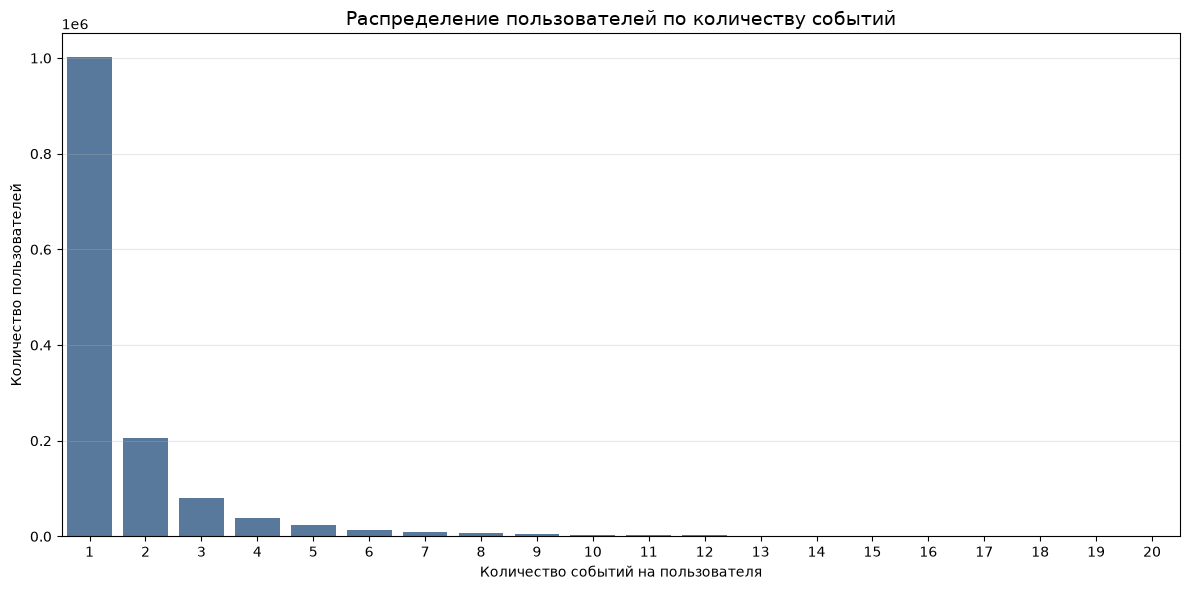

In [126]:
activity_distribution = (
    events_per_user
    .value_counts()
    .sort_index()
)

activity_first_20 = activity_distribution.loc[1:20]

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    x=activity_first_20.index,
    y=activity_first_20.values,
    color="#4C78A8",
    ax=ax,
)

ax.set_title(
    "Распределение пользователей по количеству событий",
    fontsize=14,
)

ax.set_xlabel("Количество событий на пользователя")
ax.set_ylabel("Количество пользователей")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Вывод**

Распределение пользовательской активности имеет выраженную
правостороннюю асимметрию. Большинство пользователей совершает
небольшое количество действий, при этом существует малочисленная
группа крайне активных пользователей

Поэтому среднее количество событий завышается выбросами и плохо
характеризует типичного пользователя. Для описания центральной
активности целесообразнее использовать медиану и перцентили.
Наиболее активных пользователей необходимо исследовать отдельно,
не делая преждевременного вывода о том, являются ли они реальными
покупателями, сотрудниками или автоматизированным трафиком

**Анализ наиболее активных пользователей**

_Бизнес-вопрос_: самые активные пользователи действительно ценны для магазина или они только многократно просматривают товары

In [127]:
top_user_ids = (
    events_per_user
    .nlargest(10)
    .index
)

top_users_events = events_clean[
    events_clean["visitorid"].isin(top_user_ids)
].copy()

In [128]:
top_users_event_counts = (
    top_users_events
    .groupby(
        ["visitorid", "event"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "view",
            "addtocart",
            "transaction",
        ],
        fill_value=0,
    )
)

In [129]:
top_users_metrics = (
    top_users_events
    .groupby("visitorid")
    .agg(
        total_events=("event", "size"),
        unique_items=("itemid", "nunique"),
        active_days=("event_date", "nunique"),
        first_event=("datetime", "min"),
        last_event=("datetime", "max"),
    )
    .join(top_users_event_counts)
)

In [130]:
top_users_metrics["transaction_share"] = (
    top_users_metrics["transaction"]
    / top_users_metrics["total_events"]
)

top_users_metrics = top_users_metrics.sort_values(
    "total_events",
    ascending=False,
)

display(
    top_users_metrics.style.format(
        {
            "transaction_share": "{:.2%}",
        }
    )
)

,total_events,unique_items,active_days,first_event,last_event,view,addtocart,transaction,transaction_share
visitorid,,,,,,,,,
1150086,7757,3814,74,2015-06-11 14:55:17.389000+00:00,2015-09-17 02:57:11.237000+00:00,6479,719,559,7.21%
530559,4328,2209,73,2015-06-15 18:59:25.103000+00:00,2015-09-17 02:14:14.827000+00:00,3623,419,286,6.61%
152963,3024,1622,38,2015-07-31 21:14:28.499000+00:00,2015-09-18 02:48:46.605000+00:00,2304,371,349,11.54%
895999,2474,1641,97,2015-05-06 15:10:32.815000+00:00,2015-09-18 02:41:59.083000+00:00,2368,56,50,2.02%
163561,2410,1314,21,2015-05-03 18:08:45.953000+00:00,2015-06-04 02:57:16.915000+00:00,2194,124,92,3.82%
371606,2345,1399,18,2015-06-25 19:13:49.090000+00:00,2015-07-19 21:24:06.548000+00:00,2141,110,94,4.01%
286616,2252,1230,19,2015-05-09 15:27:36.222000+00:00,2015-06-07 02:33:59.412000+00:00,2057,120,75,3.33%
684514,2246,1187,18,2015-05-31 18:41:23.341000+00:00,2015-07-06 20:16:21.983000+00:00,1826,231,189,8.41%
892013,2024,1738,42,2015-07-03 22:30:43.524000+00:00,2015-08-31 21:02:29.748000+00:00,2023,1,0,0.00%


In [131]:
top_users_metrics = top_users_metrics.rename(
    columns={
        "transaction_share": "transaction_event_share"
    }
)

In [132]:
top_users_order_metrics = (
    top_users_events.loc[
        top_users_events["event"] == "transaction"
    ]
    .groupby("visitorid")
    .agg(
        orders_count=("transactionid", "nunique"),
        unique_purchased_items=("itemid", "nunique"),
    )
)

top_users_metrics = (
    top_users_metrics
    .join(top_users_order_metrics)
)

top_users_metrics[
    ["orders_count", "unique_purchased_items"]
] = (
    top_users_metrics[
        ["orders_count", "unique_purchased_items"]
    ]
    .fillna(0)
    .astype("int64")
)

In [133]:
display(
    top_users_metrics[
        [
            "total_events",
            "active_days",
            "unique_items",
            "view",
            "addtocart",
            "transaction",
            "orders_count",
            "unique_purchased_items",
            "transaction_event_share",
        ]
    ]
    .sort_values(
        "total_events",
        ascending=False,
    )
)

,total_events,active_days,unique_items,view,addtocart,transaction,orders_count,unique_purchased_items,transaction_event_share
visitorid,,,,,,,,,
1150086,7757,74,3814,6479,719,559,502,532,0.072064
530559,4328,73,2209,3623,419,286,221,259,0.066081
152963,3024,38,1622,2304,371,349,278,319,0.115410
895999,2474,97,1641,2368,56,50,44,50,0.020210
163561,2410,21,1314,2194,124,92,81,92,0.038174
371606,2345,18,1399,2141,110,94,79,93,0.040085
286616,2252,19,1230,2057,120,75,62,72,0.033304
684514,2246,18,1187,1826,231,189,162,184,0.084150
892013,2024,42,1738,2023,1,0,0,0,0.000000


**Наиболее активные пользователи**

Среди наиболее активных пользователей наблюдаются разные модели
поведения. Часть пользователей регулярно добавляет товары в корзину
и совершает покупки, тогда как пользователь 892013 почти полностью
ограничивается просмотрами

Таким образом, количество событий не является достаточным
показателем ценности пользователя. Необходимо отдельно учитывать
число заказов, количество приобретённых товаров и структуру
совершённых действий. Из-за отсутствия информации о стоимости
заказов таких пользователей пока нельзя называть наиболее ценными
в денежном выражении

In [134]:
user_base_metrics = (
    events_clean
    .groupby("visitorid")
    .agg(
        total_events=("event", "size"),
        unique_items=("itemid", "nunique"),
        active_days=("event_date", "nunique"),
        first_event=("datetime", "min"),
        last_event=("datetime", "max"),
    )
)

In [135]:
user_event_counts = (
    events_clean
    .groupby(
        ["visitorid", "event"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "view",
            "addtocart",
            "transaction",
        ],
        fill_value=0,
    )
)

In [136]:
user_metrics = (
    user_base_metrics
    .join(user_event_counts)
)

user_metrics["has_cart"] = (
    user_metrics["addtocart"] > 0
)

user_metrics["has_purchase"] = (
    user_metrics["transaction"] > 0
)

In [137]:
print(
    "Всего пользователей:",
    len(user_metrics),
)

print(
    "Пользователей с покупкой:",
    user_metrics["has_purchase"].sum(),
)

print(
    f"Доля пользователей с покупкой: "
    f"{user_metrics['has_purchase'].mean():.2%}"
)

Всего пользователей: 1407580
Пользователей с покупкой: 11719
Доля пользователей с покупкой: 0.83%


In [138]:
purchase_comparison = (
    user_metrics
    .groupby("has_purchase")
    .agg(
        users=("total_events", "size"),
        median_events=("total_events", "median"),
        median_unique_items=("unique_items", "median"),
        median_active_days=("active_days", "median"),
    )
)

display(purchase_comparison)

,users,median_events,median_unique_items,median_active_days
has_purchase,,,,
False,1395861,1.0,1.0,1.0
True,11719,6.0,2.0,1.0


**Сравнение покупателей и не покупателей**

За рассматриваемый период покупку совершили 11 719 пользователей,
что составляет 0,83% аудитории

Медианный пользователь без покупки совершил одно событие с одним
товаром. Среди покупателей медиана составляет шесть событий и два
уникальных товара. При этом медианное число активных дней в обеих
группах равно одному

Покупатели демонстрируют более интенсивное взаимодействие с
платформой, однако наблюдаемая связь не доказывает, что увеличение
числа действий само по себе приводит к покупке

_Бизнес-вопрос_: какие действия преобладают на платформе и насколько часто пользователи доходят до более целевых действий?

In [139]:
event_summary = (
    events_clean
    .groupby(
        "event",
        observed=True,
    )
    .agg(
        events_count=("timestamp", "size"),
        unique_users=("visitorid", "nunique"),
        unique_items=("itemid", "nunique"),
    )
    .reindex(
        [
            "view",
            "addtocart",
            "transaction",
        ]
    )
)

event_summary["event_share"] = (
    event_summary["events_count"]
    / event_summary["events_count"].sum()
)

display(
    event_summary.style.format(
        {
            "events_count": "{:,.0f}",
            "unique_users": "{:,.0f}",
            "unique_items": "{:,.0f}",
            "event_share": "{:.2%}",
        }
    )
)

,events_count,unique_users,unique_items,event_share
event,,,,
view,"2,664,218","1,404,179","234,838",96.68%
addtocart,"68,966","37,722","23,903",2.50%
transaction,"22,457","11,719","12,025",0.81%


**Структура событий**

Просмотры составляют 96,68% всех событий. На добавления в корзину
приходится 2,50%, а на товарные строки покупки — 0,81%

Снижение количества событий на более целевых этапах ожидаемо для
e-commerce, однако эти доли нельзя интерпретировать как конверсию.
Для расчёта воронки необходимо определить её объект, знаменатель
и проверить последовательность действий

_Бизнес-вопрос_: Как изменялась активность магазина во времени: были ли периоды роста, снижения или аномальные всплески?

In [140]:
daily_event_counts = (
    events_clean
    .groupby(
        ["event_date", "event"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "view",
            "addtocart",
            "transaction",
        ],
        fill_value=0,
    )
)

In [141]:
daily_metrics = (
    events_clean
    .groupby("event_date")
    .agg(
        total_events=("event", "size"),
        active_users=("visitorid", "nunique"),
        unique_items=("itemid", "nunique"),
    )
    .join(daily_event_counts)
    .sort_index()
)

display(daily_metrics.head())
display(daily_metrics.tail())

,total_events,active_users,unique_items,view,addtocart,transaction
event_date,,,,,,
2015-05-03 00:00:00+00:00,13682,7865,8787,13303,296,83
2015-05-04 00:00:00+00:00,19413,11019,11567,18681,578,154
2015-05-05 00:00:00+00:00,23011,13084,13583,22225,561,225
2015-05-06 00:00:00+00:00,23920,13687,13926,23015,647,258
2015-05-07 00:00:00+00:00,23157,13086,13647,22368,572,217


,total_events,active_users,unique_items,view,addtocart,transaction
event_date,,,,,,
2015-09-14 00:00:00+00:00,20905,13389,12892,20282,469,154
2015-09-15 00:00:00+00:00,20425,12687,12272,19673,594,158
2015-09-16 00:00:00+00:00,11494,6824,7723,11022,335,137
2015-09-17 00:00:00+00:00,10126,6270,6973,9830,251,45
2015-09-18 00:00:00+00:00,1528,1016,1204,1479,34,15


In [142]:
display(
    daily_metrics
    .nlargest(10, "total_events")
)

,total_events,active_users,unique_items,view,addtocart,transaction
event_date,,,,,,
2015-07-26 00:00:00+00:00,32692,17516,13531,32077,471,144
2015-07-27 00:00:00+00:00,28555,16015,14752,27622,666,267
2015-07-25 00:00:00+00:00,27104,15571,13870,26551,437,116
2015-05-18 00:00:00+00:00,27081,15476,15675,26187,649,245
2015-07-14 00:00:00+00:00,26868,16306,15915,26007,630,231
2015-05-19 00:00:00+00:00,26797,15482,15355,25949,652,196
2015-07-13 00:00:00+00:00,26114,16515,15106,25234,664,216
2015-07-20 00:00:00+00:00,25329,15288,14873,24373,724,232
2015-07-08 00:00:00+00:00,25032,14162,14863,24084,689,259


In [143]:
display(
    daily_metrics[
        [
            "total_events",
            "active_users",
            "view",
            "addtocart",
            "transaction",
        ]
    ].describe()
)

,total_events,active_users,view,addtocart,transaction
count,139.000000,139.000000,139.000000,139.000000,139.000000
mean,19824.755396,11867.151079,19167.035971,496.158273,161.561151
std,4170.038206,2303.606146,4024.284121,124.599140,58.246368
min,1528.000000,1016.000000,1479.000000,34.000000,15.000000
25%,16829.500000,10292.000000,16344.000000,391.500000,112.500000
50%,20619.000000,12348.000000,19961.000000,509.000000,162.000000
75%,22459.500000,13151.000000,21787.500000,580.500000,207.500000
max,32692.000000,17516.000000,32077.000000,799.000000,276.000000


_Бизнес-вопрос_: как менялись посещаемость и целевые действия во времени и совпадают ли их пики и падения?